### 보행

- 정지 상태에서 Heel Strike 지점으로 진행할 때 row값이 올라갔다 내려갔다 올라가는 형태의 그래프가 그려짐. (마지막 지점이 Heel Strike)

- 

<hr>

### 피크치 검출 (Scipy find_peaks())

- 피크(Peak)란? => 가장 높은 값을 의미함.

- find_peaks() 는 두 개의 결과값을 반환한다. => peaks, properties = find_peaks(value)

##### Parameter

- find_peaks()에는 여러 가지 파라미터들이 존재함.

- find_peaks(value, height) => height에 하나의 값이 있다면, 해당 값보다 큰 threshold를 찾는다. [0, 10] 처럼 범위로 설정하여 0~10 사이의 값 중 피크치를 찾는 것도 가능함.

- distance => 서로 인접한 피크치 사이의 최소 수평 거리 (더 작은 피크치가 제거됨.) => 피크의 주기성을 알고 있을 때 매우 유용함. 

##### Returns

- peaks => 해당 조건을 전부 만족하는 Peak값

- properties => 해당 조건에 만족하는 피크의 속성을 반환하는 딕셔너리 형태

> properties['peak_heights'] => 피크치의 높이

> 등등 있음.



그래서 우리는 한 번의 보행을 할 때 주기를 구해, height 파라미터로 최소 treshold 구하고, 

distance로 지정해서 그 distance마다의 피크치를 구하면 무릎이 최대로 들릴 때의 값을 구할 수 있을 것 같음.

하지만 사람마다 보행주기가 다르기 때문에 어캐 찾아야하노,,

<hr>

## Firebase로 데이터 가져오기

In [45]:
# firebase url설정과 비공개 key 세팅

import firebase_admin
from firebase_admin import credentials
from firebase_admin import firestore
from firebase_admin import db

if not firebase_admin._apps:
    cred = credentials.Certificate("gait-analysis-7350b-firebase-adminsdk-czbst-e609643d68.json")
    firebase_admin.initialize_app(cred,{'databaseURL':'https://gait-analysis-7350b-default-rtdb.asia-southeast1.firebasedatabase.app/230128_jihun'})

In [2]:
# firebase로 값 저장, 변경, 가져오기 메서드

import numpy as np
import pandas as pd


#해당 filename에 해당하는 테이블 가져오기.
def getDataName(filename):
    dir = db.reference(filename)
    data = dir.get()
    df = pd.DataFrame(data)
    return df


#getData로 가져온 df를 다른 이름으로 저장하기.
def setData(df):
    dict = {}
    dict.update({'Roll' : df['Roll'].values.tolist()})
    dict.update({'Pitch' : df['Pitch'].values.tolist()})
    dict.update({'Yaw' : df['Yaw'].values.tolist()})
    dict.update({'Time' : df['Time'].values.tolist()})

    name = input()
    new_dir = db.reference(name)
    new_dir.update(dict)
    

#디폴트로 저장되는 테이블 이름 "input"을 df로 가져오기
def getData():    
    dir = db.reference("input") #데이터베이스에 저장되어있는 데이터 이름
    data = dir.get()
    
    dir = db.reference()
    
    data_list = np.concatenate(data).tolist()
    
    for i in range(0,len(data_list)):
        data_list[i] = data_list[i].split(',')
    
    
    df = pd.DataFrame(data_list)
    df.columns = ['Roll','Pitch','Yaw','Time']
    df = df.astype('float') 

    df['Time'] = df['Time'].apply(lambda x: x/1000)
    first_time = df['Time'].loc[0]
    df['Time'] = df['Time'].apply(lambda x: x-first_time)
    
    df = df.loc[200:,:]
    
    return df

<hr>

### 동영상 프레임 단위로 자르기

In [ ]:
import cv2
vidcap = cv2.VideoCapture('../한지훈 보행.mp4')
success,image = vidcap.read()

count = 1
success = True

while success:
  success,image = vidcap.read()
  cv2.imwrite("../Graph/%d.jpg" % count, image)
  print("saved image %d.jpg" % count)
  
  if cv2.waitKey(10) == 27:                    
      break
  count += 1

<hr>

### 데이터 분석

In [56]:
# 보행 주기에서의 Roll값의 최고점(Heel Strike)과 최저점(Toe Off) 구하기
# Scipy의 find_peaks를 이용함.
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

#최고점 (Heel Strike) 구하기
def getHighPoint(df):
    high_point, _ = find_peaks(df['Roll'], distance=10)#피크치의 최소거리는 최소 25개
    high_point = high_point.tolist()

    return high_point

#최저점 (Toe Off) 구하기
def getLowPoint(df):
    df2 = df["Roll"].apply(lambda x: -(x))   #거꾸로 뒤집은 후 피크치 구하기(최저점 구하기)
    low_point, _ = find_peaks(df2, distance=10) #distance는 임의의 적당한 값이 25이고, 실험을 진행하며 적당한 값을 찾아야 함.
    low_point = low_point.tolist()
    
    return low_point


#HighPoint와 LowPoint를 포함한 데이터프레임 플로팅
def plotting_pivot_point(df, df_high_point, df_low_point):
    # plt.plot(df['Time'], df['Roll'])
    # plt.plot(df['Time'][df_high_point], df['Roll'][df_high_point], 'x')
    # plt.plot(df['Time'][df_low_point], df['Roll'][df_low_point], 'x')
    xlabel = df.index
    plt.plot(xlabel, df['Roll'])
    plt.scatter(df_high_point, df['Roll'][df_high_point], c='r')
    plt.scatter(df_low_point, df['Roll'][df_low_point], c='g')

    plt.show()


#가만히 있을 때의 정보 3가지 return => 1. mean 2. threshold_max, 3. threshold_min
def get_mean_threshold_state_stance(df, start_point, end_point):
    #stance_point1은 시작하는 지점까지의 stance state의 roll값의 평균
    stance_point1 = df['Roll'][:start_point].mean()
    stance_point2 = df['Roll'][end_point:].mean()
    
    stance_threshold_high = df['Roll'][end_point:].max()
    stance_threshold_low = df['Roll'][end_point:].min()

    return [(stance_point1 + stance_point2) / 2, stance_threshold_high, stance_threshold_low]



<hr>

### 보행 x

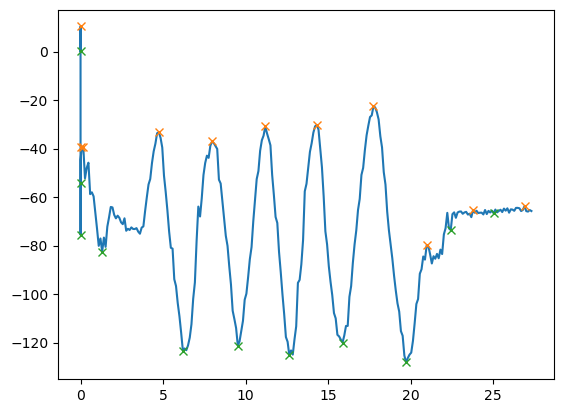

In [14]:
plotting_pivot_point(df_test2, high2, low2)

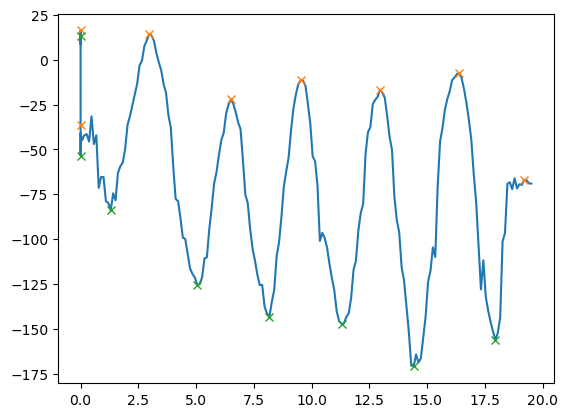

In [12]:
plotting_pivot_point(df_test1, high1, low1)

<hr>

### 김민식 (170cm 남자) 보행

### 230226

In [118]:
import pandas as pd


<hr>

### 김민식 Test1

In [47]:
minsik_test1 = pd.read_csv('../data/minsiktest1.csv')

In [51]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
minsik_test1_high_point = getHighPoint(minsik_test1)
minsik_test1_low_point = getLowPoint(minsik_test1)

In [62]:
stance_info = get_mean_threshold_state_stance(minsik_test1, 110, 210)

minsik_test1_state_stance, minsik_test1_stance_high, minsik_test1_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(minsik_test1_state_stance)
#stance 상태일 때의 high
print(minsik_test1_stance_high)
#stance 상태일 때의 low
print(minsik_test1_stance_low)

-128.1100454545454
-127.25
-128.58


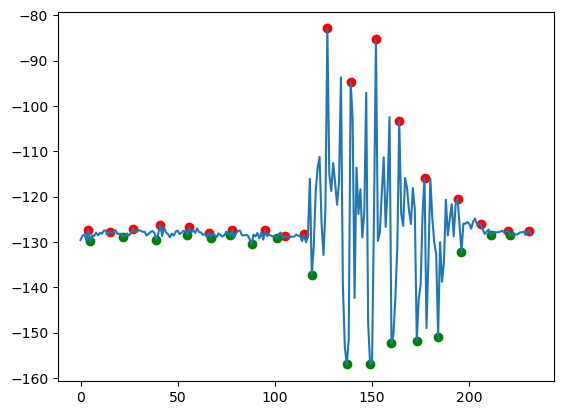

In [64]:
# 피크치 플로팅
plotting_pivot_point(minsik_test1, minsik_test1_high_point, minsik_test1_low_point)

<hr>

### 김민식 test2

In [93]:
minsik_test2 = pd.read_csv('../data/minsiktest2.csv')

<AxesSubplot:>

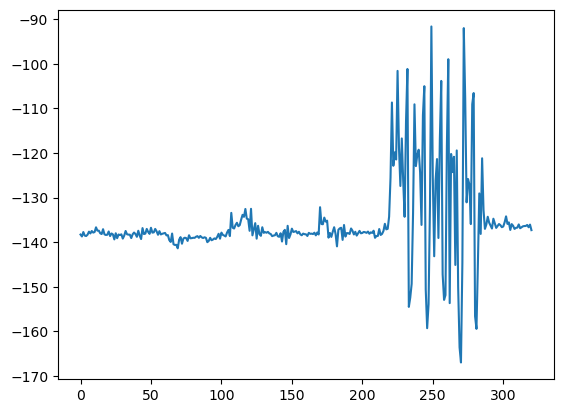

In [94]:
minsik_test2['Roll'].plot()

In [96]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
minsik_test2_high_point = getHighPoint(minsik_test2)
minsik_test2_low_point = getLowPoint(minsik_test2)

In [97]:
stance_info = get_mean_threshold_state_stance(minsik_test2, 200, 280)

minsik_test2_state_stance, minsik_test2_stance_high, minsik_test2_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(minsik_test2_state_stance)
#stance 상태일 때의 high
print(minsik_test2_stance_high)
#stance 상태일 때의 low
print(minsik_test2_stance_low)

-137.43904573170738
-121.19
-159.44


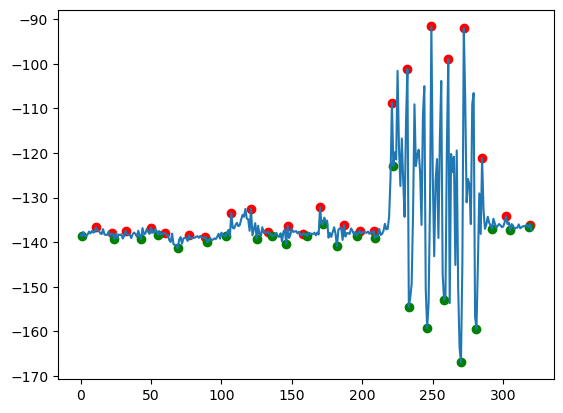

In [98]:
# 피크치 플로팅
plotting_pivot_point(minsik_test2, minsik_test2_high_point, minsik_test2_low_point)

<hr>

## 23년 02월 27일 실험 Test

#### 한지휸 Test1

In [100]:
jihun_test1 = pd.read_csv('../data/data/230227_jihun1.csv')

<AxesSubplot:>

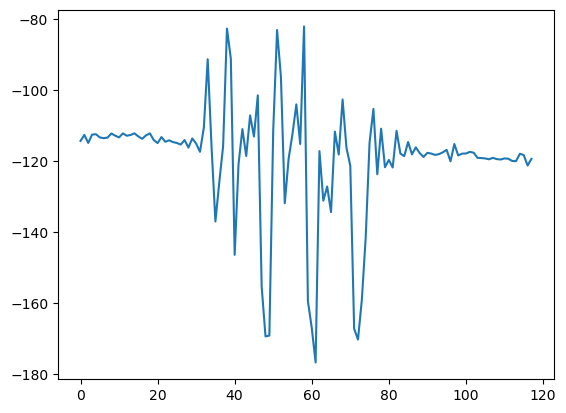

In [101]:
jihun_test1['Roll'].plot()

In [102]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
jihun_test1_high_point = getHighPoint(jihun_test1)
jihun_test1_low_point = getLowPoint(jihun_test1)

In [103]:
stance_info = get_mean_threshold_state_stance(jihun_test1, 30, 85)

jihun_test1_state_stance, jihun_test1_stance_high, jihun_test1_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(jihun_test1_state_stance)
#stance 상태일 때의 high
print(jihun_test1_stance_high)
#stance 상태일 때의 low
print(jihun_test1_stance_low)

-116.00330303030304
-114.66
-121.28


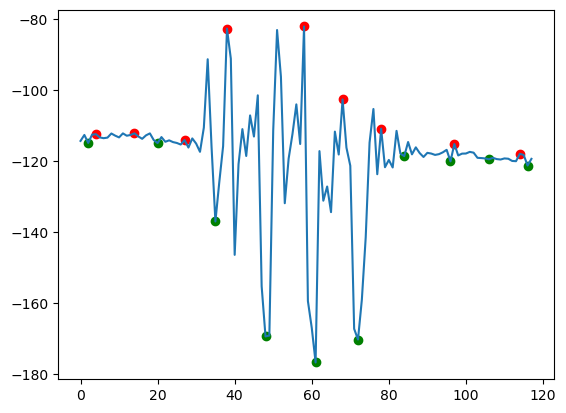

In [104]:
# 피크치 플로팅
plotting_pivot_point(jihun_test1, jihun_test1_high_point, jihun_test1_low_point)

<hr>

### 한지훈 Test2

In [105]:
jihun_test2 = pd.read_csv('../data/data/230227_jihun2.csv')

<AxesSubplot:>

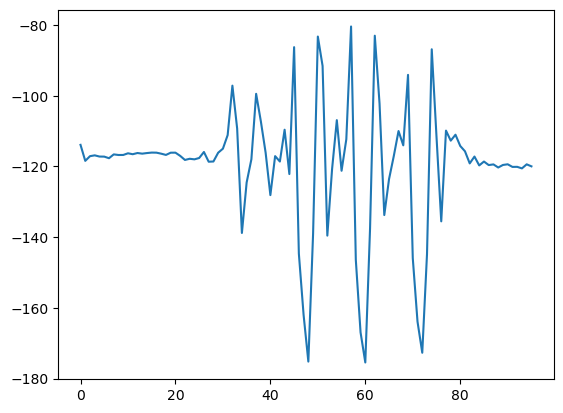

In [106]:
jihun_test2['Roll'].plot()

In [107]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
jihun_test2_high_point = getHighPoint(jihun_test2)
jihun_test2_low_point = getLowPoint(jihun_test2)

In [108]:
stance_info = get_mean_threshold_state_stance(jihun_test2, 30, 85)

jihun_test2_state_stance, jihun_test2_stance_high, jihun_test2_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(jihun_test2_state_stance)
#stance 상태일 때의 high
print(jihun_test2_stance_high)
#stance 상태일 때의 low
print(jihun_test2_stance_low)

-118.29131818181817
-118.61
-120.55


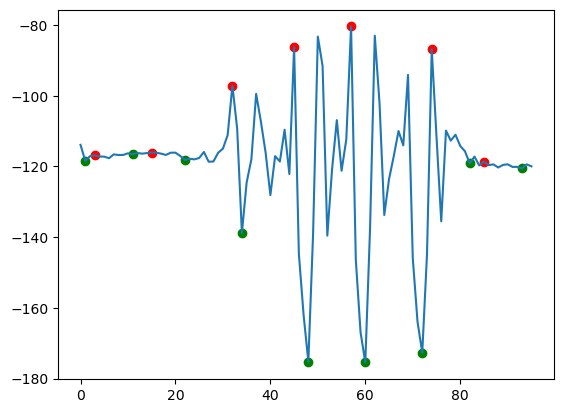

In [109]:
# 피크치 플로팅
plotting_pivot_point(jihun_test2, jihun_test2_high_point, jihun_test2_low_point)

<hr>

### 한지훈 test3

In [115]:
jihun_test3 = pd.read_csv('../data/data/230227_jihun3.csv')

<AxesSubplot:>

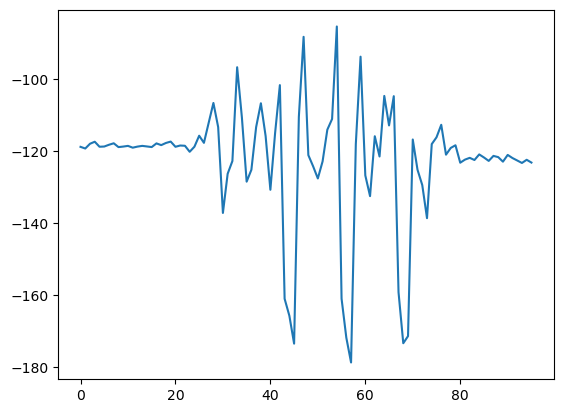

In [116]:
jihun_test3['Roll'].plot()

In [ ]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
jihun_test2_high_point = getHighPoint(jihun_test2)
jihun_test2_low_point = getLowPoint(jihun_test2)

In [ ]:
stance_info = get_mean_threshold_state_stance(jihun_test2, 30, 85)

jihun_test2_state_stance, jihun_test2_stance_high, jihun_test2_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(jihun_test2_state_stance)
#stance 상태일 때의 high
print(jihun_test2_stance_high)
#stance 상태일 때의 low
print(jihun_test2_stance_low)

-118.29131818181817
-118.61
-120.55


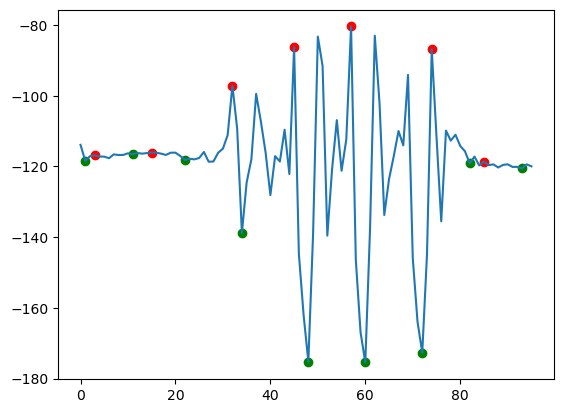

In [ ]:
# 피크치 플로팅
plotting_pivot_point(jihun_test2, jihun_test2_high_point, jihun_test2_low_point)

<AxesSubplot:>

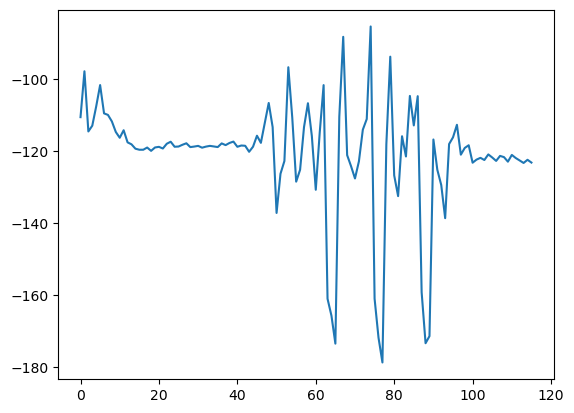

In [42]:
jihun_df3['Roll'].plot()

In [43]:
jihun_df3_highPoint = getHighPoint(jihun_df3)
jihun_df3_lowPoint = getLowPoint(jihun_df3)

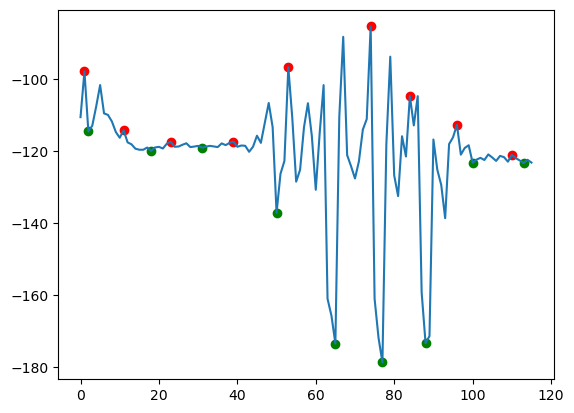

In [44]:
plotting_pivot_point(jihun_df3, jihun_df3_highPoint, jihun_df3_lowPoint)

<hr>

## 김민정 Test (162cm 여자) 23년 02월 27일자 실험

In [81]:
minjung_test2 = pd.read_csv('../data/data/230227_minjung2.csv')

<AxesSubplot:>

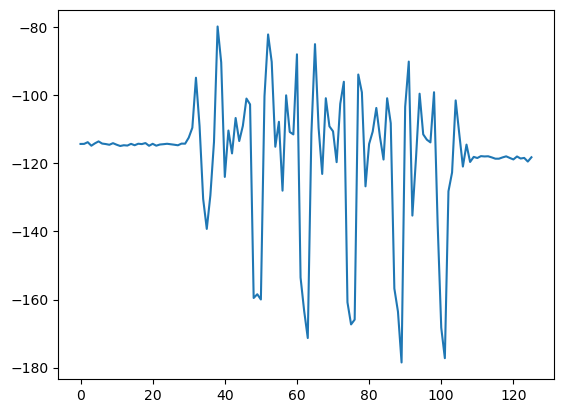

In [82]:
minjung_test2['Roll'].plot()

In [83]:
#피실험자의 최고점 피크치(Heel Strike)와 최저점 피크치(Toe Off)의 인덱스
minjung_test2_high_point = getHighPoint(minjung_test2)
minjung_test2_low_point = getLowPoint(minjung_test2)

In [84]:
stance_info = get_mean_threshold_state_stance(minjung_test2, 45, 110)

minjung_test2_state_stance, minjung_test2_stance_high, minjung_test2_stance_low = stance_info[0], stance_info[1], stance_info[2]

#stance 상태일 때의 평균
print(minjung_test2_state_stance)
#stance 상태일 때의 high
print(minjung_test2_stance_high)
#stance 상태일 때의 low
print(minjung_test2_stance_low)

-115.98925000000001
-117.89
-119.48


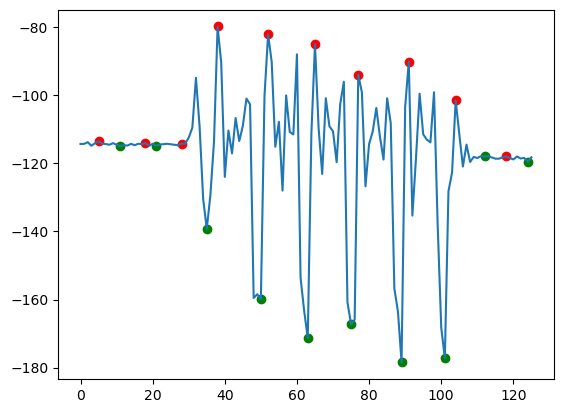

In [85]:
# 피크치 플로팅
plotting_pivot_point(minjung_test2, minjung_test2_high_point, minjung_test2_low_point)